# 10 · Historical NYC input audit

This notebook records the initial inspection of 13 NYC L2A candidate windows on 21 September and 18 October 2024. It established that the bands aligned spatially but differed in processing level from the L1C training imagery.

**The matching L1C inputs have since been downloaded and used in Notebook 11.** This short audit explains that data-selection decision; it is not a prerequisite for rerunning final inference.

## 1. Candidate inputs and metadata

Read the original local candidate chips and source metadata. Convert DN using each asset's recorded scale and offset exactly once. L2A surface reflectance and L1C top-of-atmosphere reflectance are different products.

Sources: [Sentinel-2 products](https://sentiwiki.copernicus.eu/web/s2-products) · [Earth Search scale/offset conventions](https://github.com/Element84/earth-search#gainoffset-in-items-after-jan-25-2022).

In [1]:
from pathlib import Path
import json,csv
import numpy as np
import rasterio
from rasterio.warp import reproject,Resampling,transform
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display,Markdown
ROOT=Path.cwd() if (Path.cwd()/"data").exists() else Path.cwd().parent
CHIPS=ROOT/"data/nyc/candidate_chips"
OUT=ROOT/"outputs/nyc_readiness";OUT.mkdir(parents=True,exist_ok=True)
config=json.loads((ROOT/"configs/datasets/nyc_candidates.json").read_text(encoding="utf-8"))
scenes=[s for s in config["scenes"] if s["kind"]=="s2_l2a"]
bands=["red","green","blue","nir"]
def table(rows,cols):
    def fmt(v):return f"{v:.4f}" if isinstance(v,float) else str(v)
    display(Markdown("\n".join(["|"+"|".join(cols)+"|","|"+"---|"*len(cols)]+
        ["|"+"|".join(fmt(r[c]) for c in cols)+"|" for r in rows])))
def save_csv(name,rows):
    with (OUT/name).open("w",newline="",encoding="utf-8-sig") as f:
        w=csv.DictWriter(f,fieldnames=list(rows[0]));w.writeheader();w.writerows(rows)

## 2. Grid alignment and local quality

Compare raster dimensions, coordinate systems and affine transforms across RGB and NIR. Sample the quality layer at the actual station coordinates and summarize local SCL coverage. SCL is quality information, not a water label.

In [2]:
records=[];metadata=[];previews={}
for scene in scenes:
    folder=CHIPS/scene["kind"]/scene["date"]
    item=json.loads((folder/"source_item.json").read_text(encoding="utf-8"))
    for band in bands:
        m=item["assets"][band]["raster:bands"][0]
        metadata.append(dict(date=scene["date"],band=band,scale=m["scale"],offset=m.get("offset",0),
            nodata=m["nodata"],item_boa_flag=item["properties"].get("earthsearch:boa_offset_applied")))
    for site in scene["sites"]:
        arrays=[];grids=[]
        for band in bands:
            m=item["assets"][band]["raster:bands"][0]
            with rasterio.open(folder/site["sensor_id"]/f"{band}.tif") as src:
                raw=src.read(1,masked=True).astype("float32").filled(np.nan)
                arrays.append(raw*float(m["scale"])+float(m.get("offset",0)))
                grids.append((src.shape,src.crs,src.transform));profile=src.profile.copy()
        aligned=all(grid==grids[0] for grid in grids)
        assert aligned, "RGB and NIR grids must match before stacking."
        x=np.stack(arrays);finite=np.isfinite(x).all(axis=0)
        with rasterio.open(folder/site["sensor_id"]/"scl.tif") as src:
            scl=np.zeros(x.shape[1:],dtype="uint8")
            reproject(src.read(1),scl,src_transform=src.transform,src_crs=src.crs,
                dst_transform=profile["transform"],dst_crs=profile["crs"],resampling=Resampling.nearest)
            scl_res=abs(src.res[0])
        xx,yy=transform("EPSG:4326",profile["crs"],[float(site["longitude"])],[float(site["latitude"])])
        col,row=(~profile["transform"])*(xx[0],yy[0]);ri,ci=int(np.floor(row)),int(np.floor(col))
        valid_scl=scl!=0
        rec=dict(date=scene["date"],sensor=site["sensor_name"],sensor_id=site["sensor_id"],
            utc=item["properties"]["datetime"],height=x.shape[1],width=x.shape[2],
            pixel_m=abs(profile["transform"].a),scl_native_m=scl_res,aligned=aligned,
            valid_fraction=float(finite.mean()),cloud_shadow_fraction=float(np.isin(scl,[3,8,9,10])[valid_scl].mean()),
            other_invalid_snow_fraction=float(np.isin(scl,[0,1,11]).mean()),sensor_scl=int(scl[ri,ci]),
            red_median=float(np.nanmedian(x[0])),nir_median=float(np.nanmedian(x[3])),
            inference_status="Need matched L1C; no pixel truth")
        records.append(rec)
        if scene["date"] not in previews:previews[scene["date"]]=(x,scl,site,col,row)
metadata_cols=["date","band","scale","offset","nodata","item_boa_flag"]
table(metadata,metadata_cols)
table(records,["date","sensor","pixel_m","aligned","valid_fraction","cloud_shadow_fraction","sensor_scl"])
save_csv("nyc_asset_scaling.csv",metadata);save_csv("nyc_input_audit.csv",records)
print("Site-date windows:",len(records),"| distinct sites:",len({r['sensor_id'] for r in records}))

|date|band|scale|offset|nodata|item_boa_flag|
|---|---|---|---|---|---|
|2024-09-21|red|0.0001|-0.1000|0|True|
|2024-09-21|green|0.0001|-0.1000|0|True|
|2024-09-21|blue|0.0001|-0.1000|0|True|
|2024-09-21|nir|0.0001|-0.1000|0|True|
|2024-10-18|red|0.0001|-0.1000|0|True|
|2024-10-18|green|0.0001|-0.1000|0|True|
|2024-10-18|blue|0.0001|-0.1000|0|True|
|2024-10-18|nir|0.0001|-0.1000|0|True|

|date|sensor|pixel_m|aligned|valid_fraction|cloud_shadow_fraction|sensor_scl|
|---|---|---|---|---|---|---|
|2024-09-21|Q - Beach 84 St|10.0000|True|1.0000|0.0000|5|
|2024-09-21|Q - Davenport Ct 1|10.0000|True|1.0000|0.0000|5|
|2024-09-21|Q - Russell St 1|10.0000|True|1.0000|0.0000|5|
|2024-09-21|Q - 102nd St/160th Ave|10.0000|True|1.0000|0.0000|5|
|2024-09-21|Q - 1st St/104th St|10.0000|True|1.0000|0.0000|5|
|2024-09-21|Q - 161st Ave/99th St|10.0000|True|1.0000|0.0000|5|
|2024-09-21|SI - Ridgewood Ave/Arthur Kill Rd|10.0000|True|0.5469|0.0000|5|
|2024-09-21|Q - Church Rd/E 7th Rd|10.0000|True|1.0000|0.0000|5|
|2024-10-18|Q - Russell St 1|10.0000|True|1.0000|0.0000|5|
|2024-10-18|Q - Brookville Blvd/ Snake Rd 1|10.0000|True|0.9998|0.0000|5|
|2024-10-18|Q - Davenport Ct 1|10.0000|True|0.9999|0.0000|5|
|2024-10-18|Q - 1st St/104th St|10.0000|True|1.0000|0.0000|5|
|2024-10-18|BX - Ditmars St/Hunter Ave 2|10.0000|True|0.9998|0.0000|4|

Site-date windows: 13 | distinct sites: 10


## 3. Candidate previews

Show one fixed site per date, with the FloodNet location marked by a cross. RGB stretching is for display only. The audit uses the original L2A candidates; final model inference uses the downloaded L1C inputs in Notebook 11.

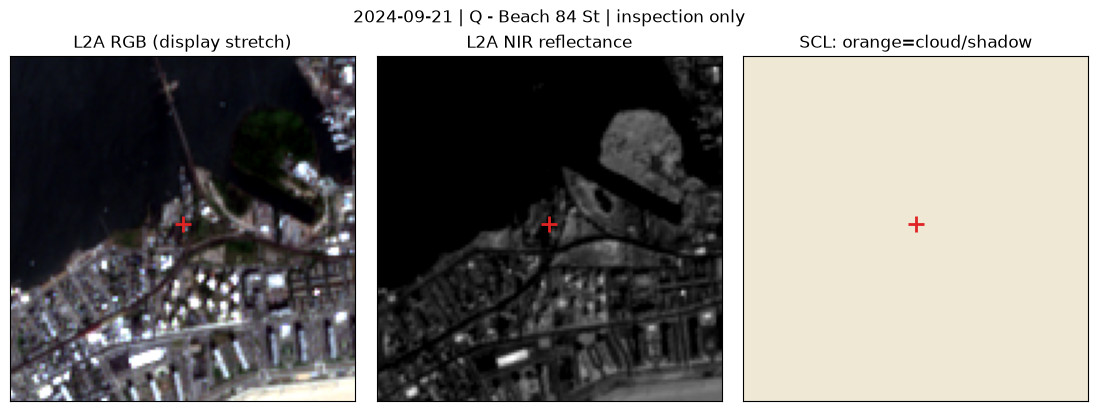

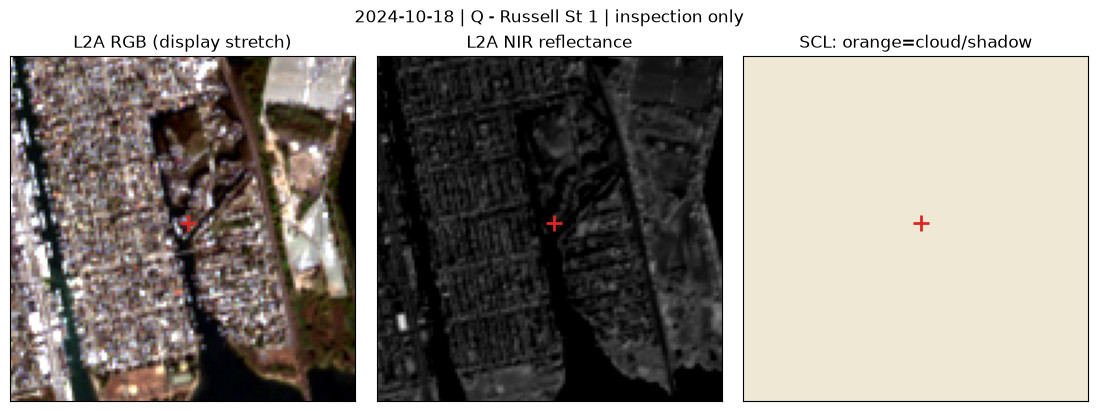

In [3]:
for date,(x,scl,site,col,row) in previews.items():
    rgb=np.moveaxis(x[:3],0,-1);valid=np.isfinite(rgb).all(axis=-1)
    lo,hi=np.percentile(rgb[valid],[2,98],axis=0)
    rgb=np.nan_to_num(np.clip((rgb-lo)/np.maximum(hi-lo,1e-6),0,1))
    fig,axes=plt.subplots(1,3,figsize=(11,4),layout="constrained")
    axes[0].imshow(rgb);axes[0].set_title("L2A RGB (display stretch)")
    axes[1].imshow(x[3],cmap="gray",vmin=0,vmax=.6);axes[1].set_title("L2A NIR reflectance")
    quality=np.zeros_like(scl);quality[np.isin(scl,[3,8,9,10])]=1;quality[np.isin(scl,[0,1,11])]=2
    axes[2].imshow(quality,cmap=ListedColormap(["#eee8d5","#df893b","#d7dee7"]),vmin=0,vmax=2,interpolation="nearest")
    axes[2].set_title("SCL: orange=cloud/shadow")
    for ax in axes:
        ax.plot(col-.5,row-.5,"+",color="#e02424",markersize=12,markeredgewidth=2)
        ax.set_xticks([]);ax.set_yticks([])
    fig.suptitle(f"{date} | {site['sensor_name']} | inspection only")
    fig.savefig(OUT/f"nyc_{date}_preview.png",dpi=150);plt.show();plt.close(fig)

## Data-selection outcome

The bands were spatially aligned, but the processing-level mismatch required L1C imagery. The completed download and product metadata are stored under `data/nyc/l1c_chips/`. The obsolete live catalog lookup has been removed from this notebook.

Continue with [11 · L1C inputs and fixed-model inference](11_nyc_l1c_inference.ipynb).